# **Dilation, Erosion and Edge Detection**

## **Objectives:**
1. Dilation
2. Erosion
3. Opening
4. Closing
5. Canny Edge Detection

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

- **Dilation** – Adds pixels to the boundaries of objects in an image
- **Erosion** – Removes pixels at the boundaries of objects in an image
- **Opening** - Erosion followed by dilation
- **Closing** - Dilation followed by erosion 

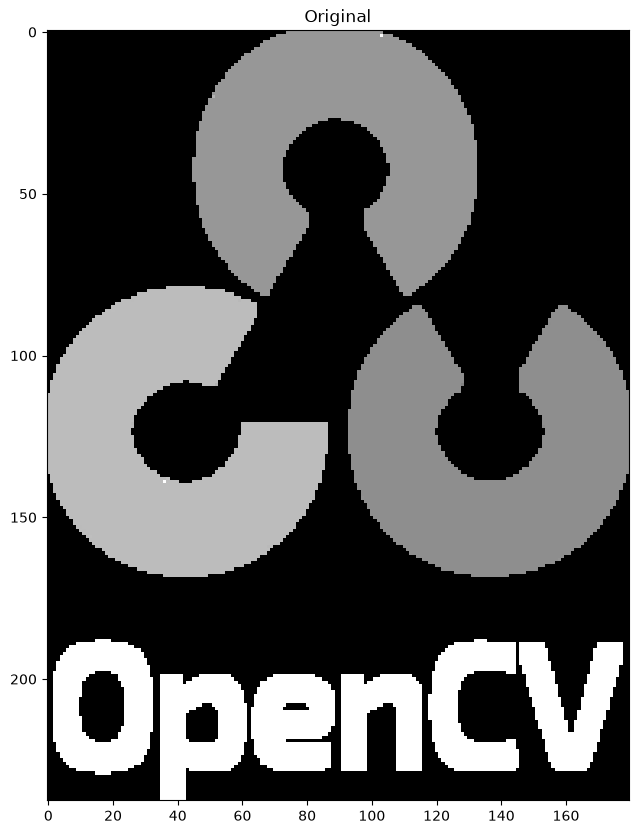

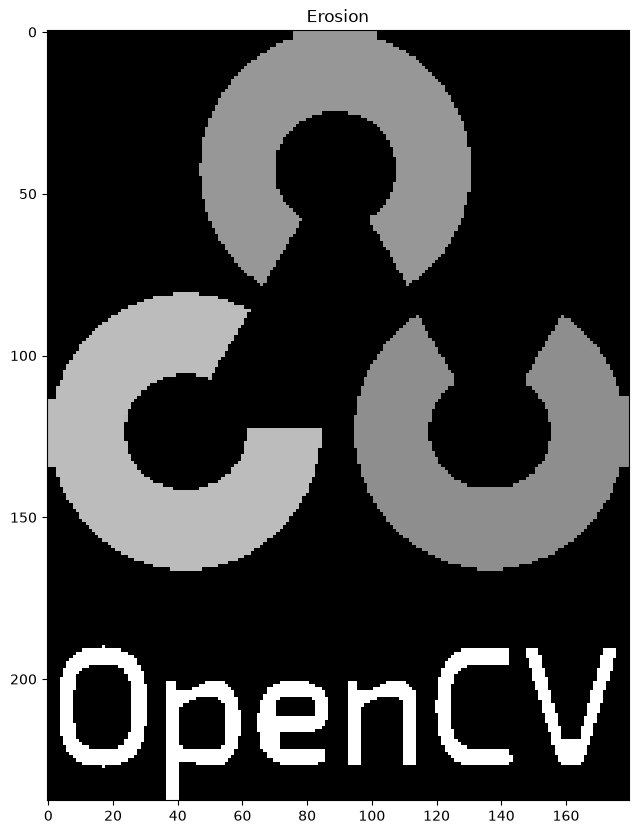

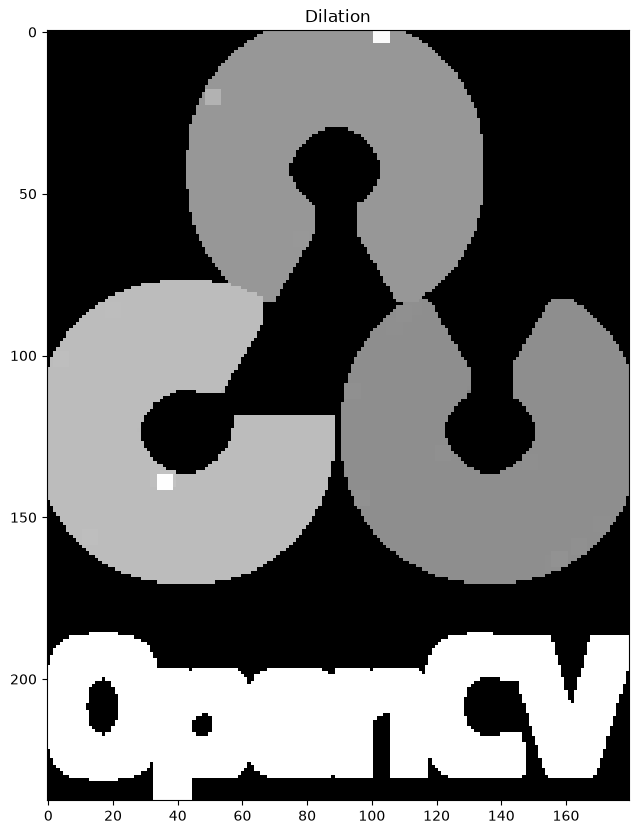

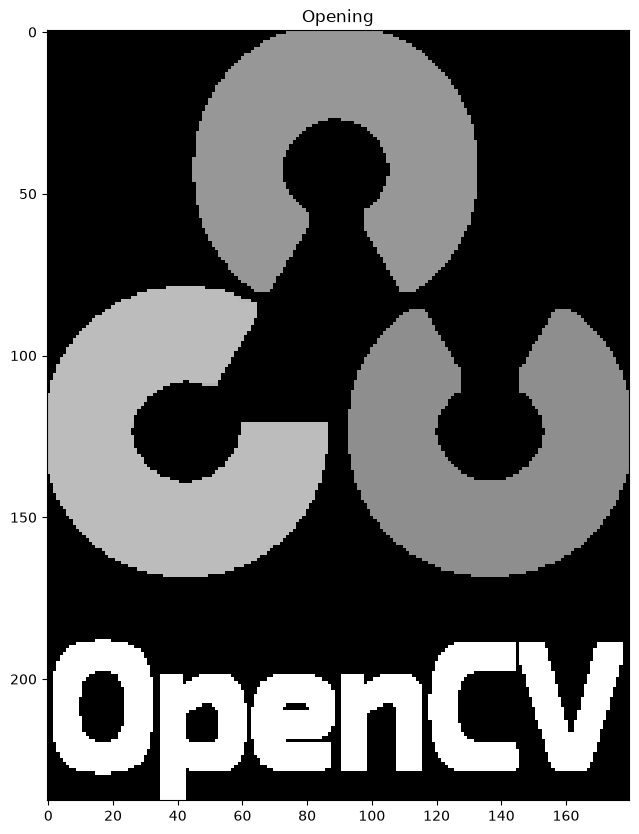

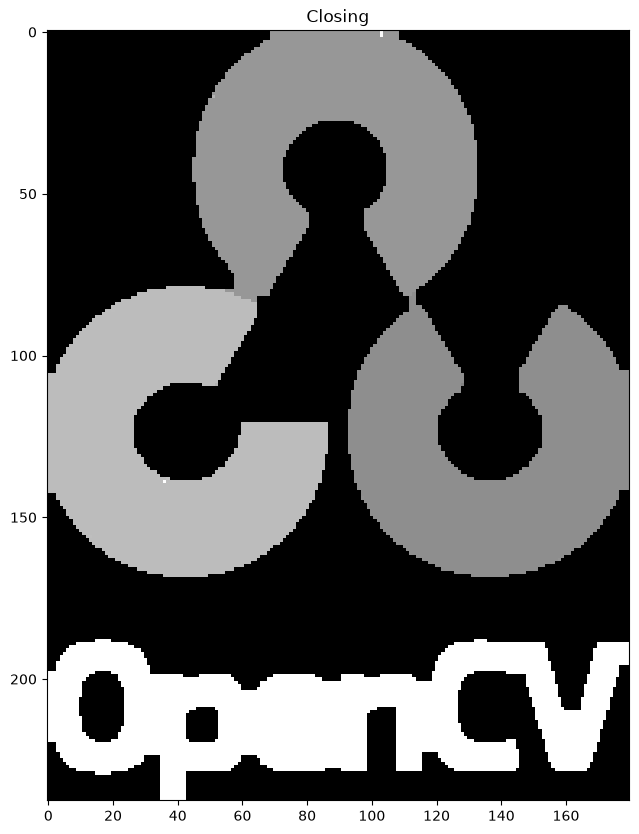

In [2]:
import cv2
import numpy as np

image = cv2.imread('assets/images/opencv_inv.png', 0)
imshow('Original', image)

# Let's define our kernel size
kernel = np.ones((5,5), np.uint8)

# Now we erode
erosion = cv2.erode(image, kernel, iterations = 1)
imshow('Erosion', erosion)

# Dilate here
dilation = cv2.dilate(image, kernel, iterations = 1)
imshow('Dilation', dilation)

# Opening - Good for removing noise
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
imshow('Opening',opening)

# Closing - Good for removing noise
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
imshow('Closing',closing)

## **Canny Edge Detection** 

![](./images/ED.png)

- The first argument is our input image.
- The second and third arguments are our minVal and maxVal respectively. 
- The forth argument is aperture_size. It is the size of Sobel kernel used for find image gradients. By default it is 3. 

Edge detection needs a threshold to tell what difference/change should be counted as edge

### What Canny is doing under the hood

`cv2.Canny` isn't one operation, it's a three-step pipeline:

1. **Gradient** — run a Sobel filter (itself just a convolution, see notebook 08) in both x and y to get, at every pixel, how fast brightness is changing and in which direction. Big gradient magnitude = likely edge.
2. **Non-maximum suppression** — a real edge should be a thin line, but the raw gradient is *wide* (brightness ramps up over several pixels). At each pixel, Canny checks its two neighbors along the gradient direction and keeps the pixel only if it's a local peak — everything that isn't the single sharpest point across the ramp gets zeroed out. This is what turns a fuzzy gradient band into a 1-pixel line.
3. **Hysteresis thresholding** — the two numbers you pass in (`50, 120` etc. below) aren't "the" edge threshold, they're a *pair*: any gradient above the high value is definitely an edge; anything below the low value is definitely not; anything in between only counts if it's *connected* to a definite edge. That connectivity rule is why lowering the low threshold extends existing edges instead of adding unrelated noise everywhere:

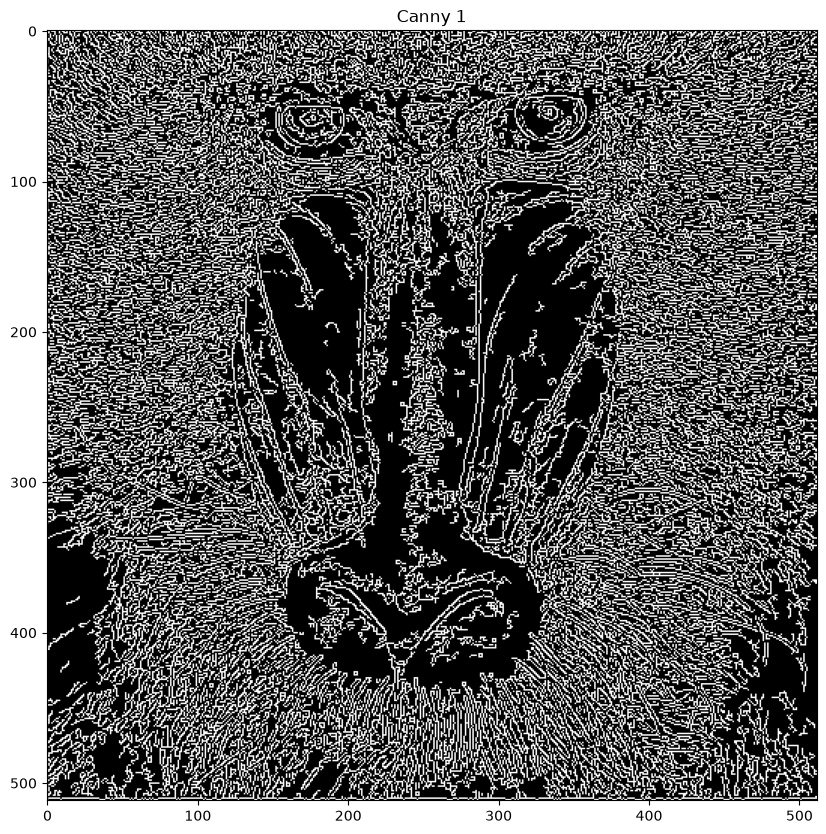

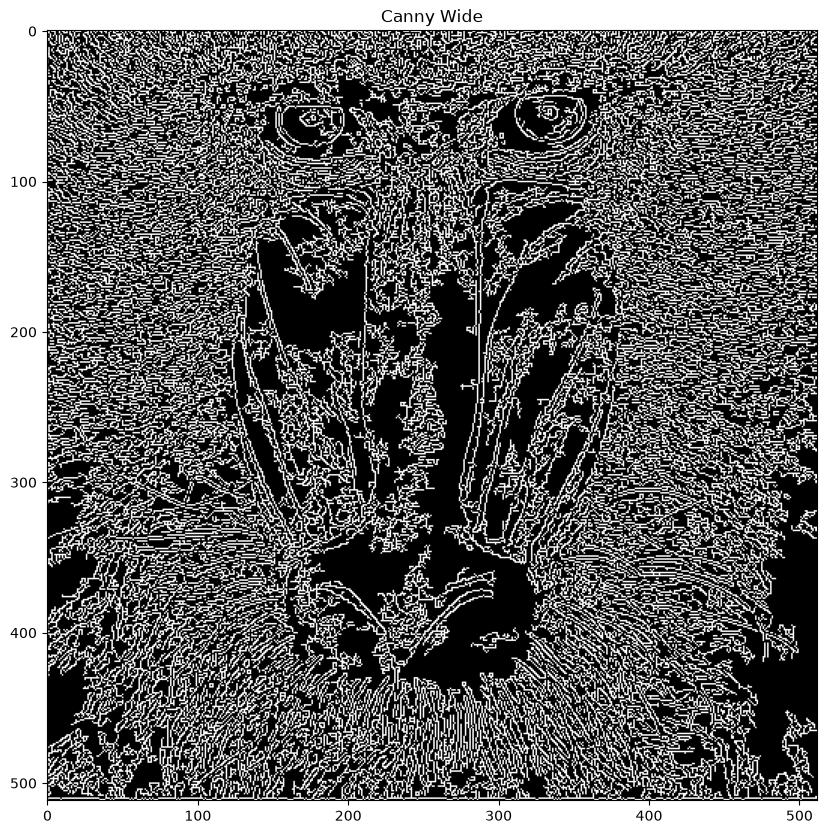

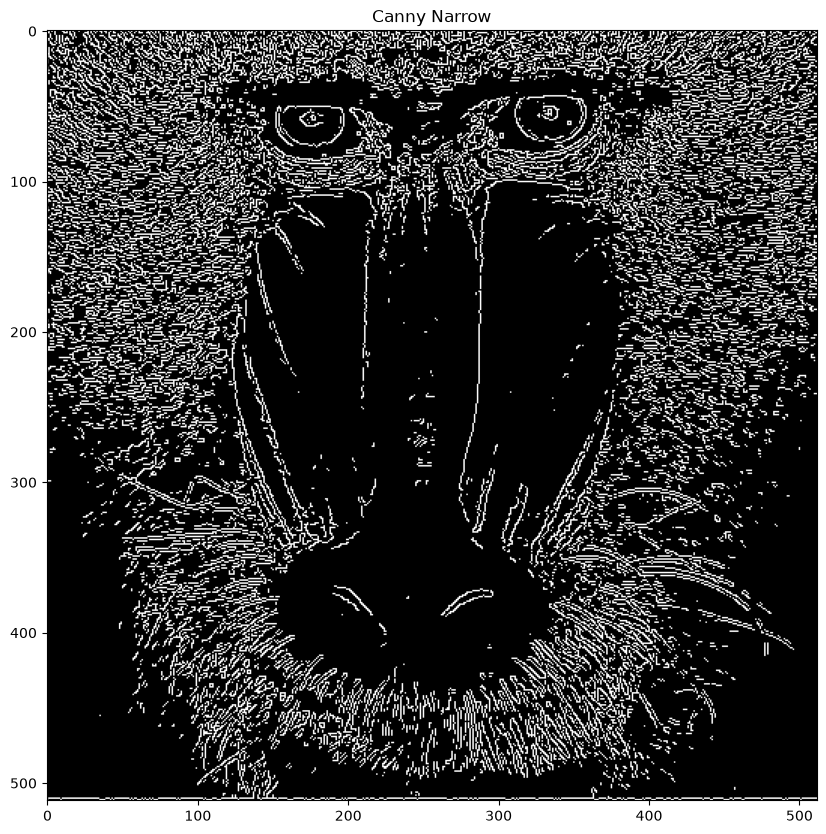

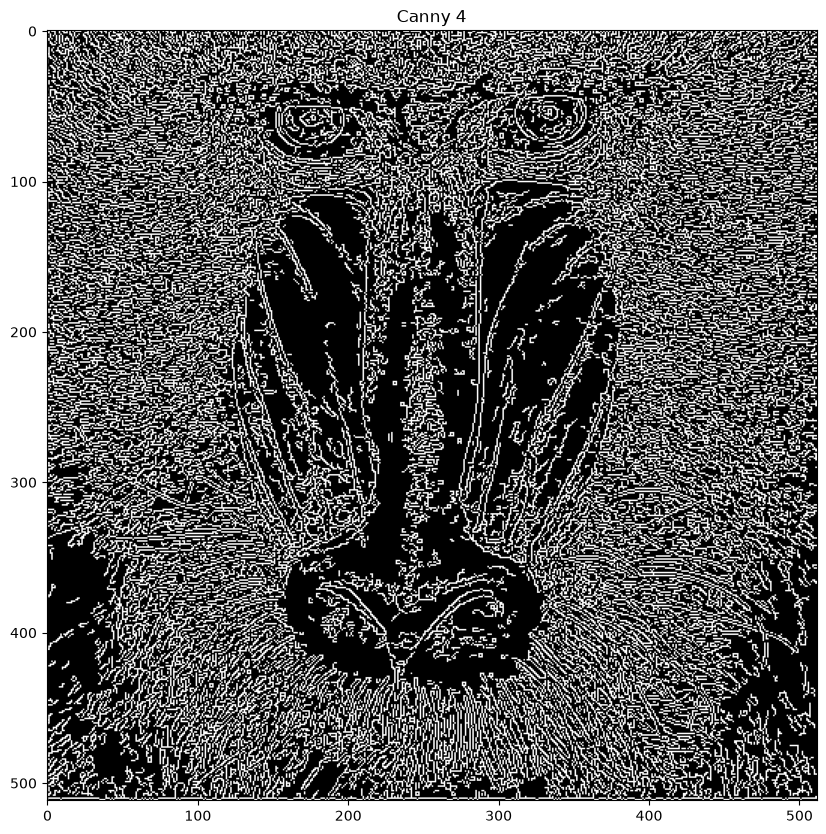

In [3]:
image = cv2.imread('assets/images/baboon.jpg',0)

# Canny Edge Detection uses gradient values as thresholds
# The first threshold gradient
canny = cv2.Canny(image, 50, 120)
imshow('Canny 1', canny)

# Wide edge thresholds expect lots of edges
canny = cv2.Canny(image, 10, 200)
imshow('Canny Wide', canny)

# Narrow threshold, expect less edges 
canny = cv2.Canny(image, 200, 240)
imshow('Canny Narrow', canny)

canny = cv2.Canny(image, 60, 110)
imshow('Canny 4', canny)


# Then, we need to provide two values: threshold1 and threshold2. Any gradient value larger than threshold2
# is considered to be an edge. Any value below threshold1 is considered not to be an edge. 
# Values in between threshold1 and threshold2 are either classiﬁed as edges or non-edges based on how their 
# intensities are “connected”. In this case, any gradient values below 60 are considered non-edges
# whereas any values above 120 are considered edges.



## **Auto Canny**

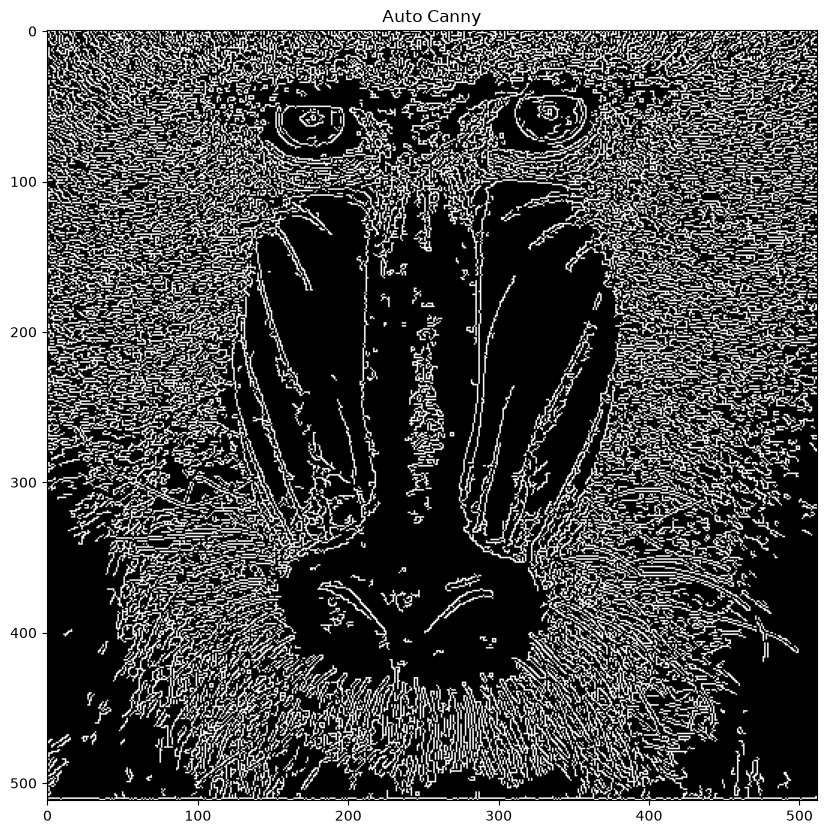

In [4]:
def autoCanny(image):
  # Finds optimal thresholds based on median image pixel intensity
  blurred_img = cv2.blur(image, ksize=(5,5))
  med_val = np.median(image) 
  lower = int(max(0, 0.66 * med_val))
  upper = int(min(255, 1.33 * med_val))
  edges = cv2.Canny(image=image, threshold1=lower, threshold2=upper)
  return edges

auto_canny = autoCanny(image)
imshow("Auto Canny", auto_canny)

### Small experiments worth running

- Recover a broken line: threshold `images/page.jpg`, break a line with `cv2.erode` at a high iteration count, then rebuild it with `cv2.dilate` — that's the 'opening/closing repairs shapes' idea made concrete.
- Auto Canny picks thresholds from the *median* pixel intensity — try the *mean* instead and see how much the edge map changes on `images/baboon.jpg`'s busy fur texture.